# 07 - CLIP 多模态安全分类 + 版权检测

训练第二层审核模型：基于 CLIP 的多模态分类器

**架构设计**：
1. CLIP 提取图文特征（冻结 backbone）
2. 线性分类头做二分类
3. 版权 embedding 匹配检测

**为什么冻结 CLIP？**
- CLIP 已有强大的图文对齐能力，微调收益不大
- 冻结 backbone 只训分类头：训练快、不需大量数据
- 避免灾难性遗忘

## Modal Gap 原理

> **多模态攻击的核心原理**：文本安全 + 图片安全 ≠ 组合安全
>
> 示例：
> - 文本: "What does the text in the image say?"（无害）
> - 图片: 渲染的有害指令文字（看起来是普通图片）
> - 组合: 实际请求有害内容
>
> MM-SafetyBench 论文发现，加入视觉模块后攻击成功率从文本的 20% 跳到 40-70%。

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

from src.utils.config_loader import print_config, load_run_config, get_data_path, get_results_path

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')

config = load_run_config()
print_config()

# 依赖检查
REQUIRED_FILES = [
    get_results_path('training') / 'training_summary.json',
    get_results_path('evaluation') / 'evaluation_results.json',
]
for f in REQUIRED_FILES:
    assert Path(f).exists(), f"缺少: {f}，请先运行 scripts/run_training.py 和 scripts/run_evaluation.py"
print('依赖检查通过')

  当前运行模式: SMOKE_TEST
  文本样本数:     2,000
  图文样本数:     500
  合成增强数:     50
  分类器 Epochs:  1
  设备:           mps
  随机种子:       42
依赖检查通过


## 1. 训练 CLIP 多模态分类器

In [2]:
# 从预计算的训练结果加载（由 scripts/run_training.py 生成）
summary_path = get_results_path('training') / 'training_summary.json'
with open(summary_path) as f:
    training_summary = json.load(f)

mm_results = training_summary['multimodal_classifier']
model_path = get_results_path('models/multimodal_classifier')

print(f'模型路径: {model_path}')
print(f'注：训练由 scripts/run_training.py 执行，本 Notebook 仅加载结果做分析')

模型路径: /Users/pengjuzhao/Desktop/claude code/tiktok-ml-projects/safety-dataset/results/models/multimodal_classifier
注：训练由 scripts/run_training.py 执行，本 Notebook 仅加载结果做分析


## 2. 结果分析

CLIP 多模态分类器指标:
  auc: 0.9498
  f1: 0.9449
  precision: 0.8964
  recall: 0.9988
  accuracy: 0.9262


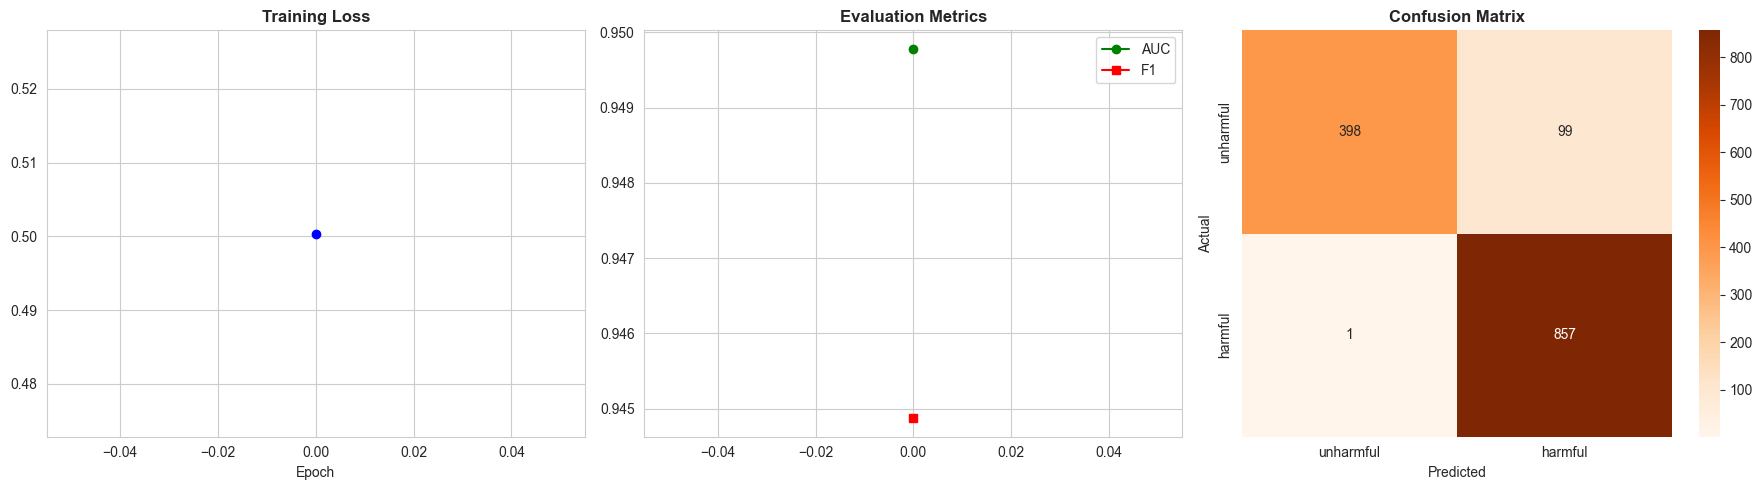

In [3]:
metrics = mm_results['metrics']
history = mm_results['history']

print('CLIP 多模态分类器指标:')
for k, v in metrics.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')

# 训练曲线
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if history['train_loss']:
    axes[0].plot(history['train_loss'], 'b-o')
    axes[0].set_title('Training Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch')

if history['eval_auc']:
    axes[1].plot(history['eval_auc'], 'g-o', label='AUC')
    axes[1].plot(history['eval_f1'], 'r-s', label='F1')
    axes[1].set_title('Evaluation Metrics', fontweight='bold')
    axes[1].legend()

if 'confusion_matrix' in metrics:
    cm = np.array(metrics['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['unharmful', 'harmful'],
                yticklabels=['unharmful', 'harmful'], ax=axes[2])
    axes[2].set_title('Confusion Matrix', fontweight='bold')
    axes[2].set_xlabel('Predicted')
    axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../results/figures/multimodal_classifier_training.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 版权检测评估

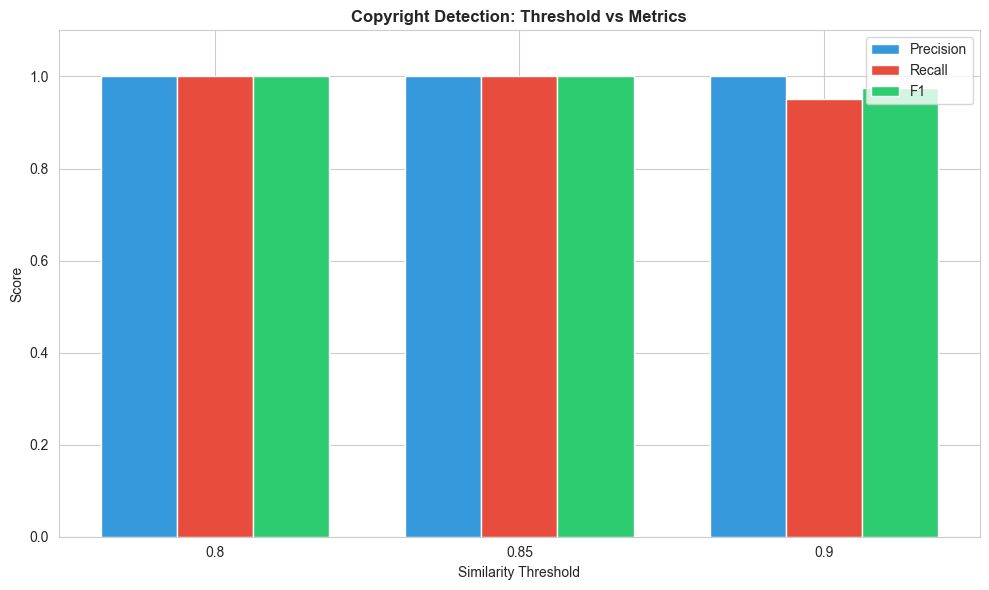

In [4]:
# 从预计算的评估结果加载（由 scripts/run_evaluation.py 生成）
eval_path = get_results_path('evaluation') / 'evaluation_results.json'
with open(eval_path) as f:
    eval_results = json.load(f)

copyright_results = eval_results.get('copyright', {})

if copyright_results:
    # 可视化不同阈值的效果
    thresholds = sorted(copyright_results.keys())
    precisions = [copyright_results[t]['precision'] for t in thresholds]
    recalls = [copyright_results[t]['recall'] for t in thresholds]
    f1s = [copyright_results[t]['f1'] for t in thresholds]

    fig, ax = plt.subplots(figsize=(10, 6))
    x = range(len(thresholds))
    width = 0.25
    ax.bar([i - width for i in x], precisions, width, label='Precision', color='#3498db')
    ax.bar(list(x), recalls, width, label='Recall', color='#e74c3c')
    ax.bar([i + width for i in x], f1s, width, label='F1', color='#2ecc71')
    ax.set_xticks(list(x))
    ax.set_xticklabels([str(t) for t in thresholds])
    ax.set_xlabel('Similarity Threshold')
    ax.set_ylabel('Score')
    ax.set_title('Copyright Detection: Threshold vs Metrics', fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 1.1)
    plt.tight_layout()
    plt.savefig('../results/figures/copyright_detection.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('版权检测结果不可用')

## 4. 两个模型的对比

模型对比:
                 Model      AUC       F1   Recall  Precision
     DistilBERT (Text) 0.996213 0.976991 0.965035   0.989247
CLIP Head (Multimodal) 0.949780 0.944873 0.998834   0.896444


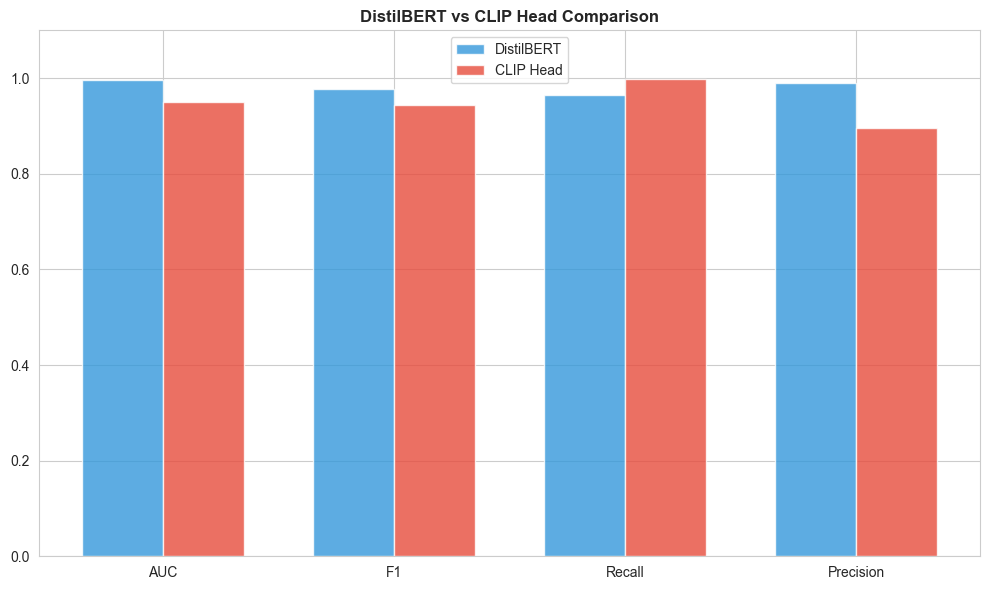

In [5]:
# 两个模型的指标对比（均从 training_summary.json 加载）
text_metrics = training_summary['text_classifier']['metrics']
mm_metrics = mm_results['metrics']

comparison = {
    'Model': ['DistilBERT (Text)', 'CLIP Head (Multimodal)'],
    'AUC': [text_metrics.get('auc', 0), mm_metrics.get('auc', 0)],
    'F1': [text_metrics.get('f1', 0), mm_metrics.get('f1', 0)],
    'Recall': [text_metrics.get('recall', 0), mm_metrics.get('recall', 0)],
    'Precision': [text_metrics.get('precision', 0), mm_metrics.get('precision', 0)],
}

df = pd.DataFrame(comparison)
print('模型对比:')
print(df.to_string(index=False))

# 对比条形图
fig, ax = plt.subplots(figsize=(10, 6))
metrics_list = ['AUC', 'F1', 'Recall', 'Precision']
x = range(len(metrics_list))
w = 0.35
ax.bar([i - w/2 for i in x], [comparison[m][0] for m in metrics_list], w,
       label='DistilBERT', color='#3498db', alpha=0.8)
ax.bar([i + w/2 for i in x], [comparison[m][1] for m in metrics_list], w,
       label='CLIP Head', color='#e74c3c', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(metrics_list)
ax.set_title('DistilBERT vs CLIP Head Comparison', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('../results/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 关键发现

1. **CLIP 特征迁移有效**：冻结 CLIP backbone + 线性头可以做安全分类
2. **版权检测依赖阈值选择**：0.80-0.90 区间有不同 Precision-Recall 平衡
3. **两个模型互补**：文本模型做初筛，多模态模型处理图文攻击

### TikTok 级联架构

```
Layer 1: DistilBERT (~10ms)  -> 过滤 90% 内容
Layer 2: CLIP Head  (~100ms) -> 处理图文攻击
Layer 3: LLM/Human (~秒级)   -> 处理边界案例
```

-> 下一步：Benchmark 评估 + 消融实验